In [ ]:
from torchvision import transforms

import __future__
from __future__ import print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
import torchvision.models as models

import os
import imageio
import torchvision
from torch.utils.data import Dataset
from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix

In [ ]:
torch_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", torch_device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

else:
    print("No GPU detected")

Using device: cuda
GPU name: NVIDIA A100-SXM4-80GB
CUDA version: 12.8


In [ ]:
raw_data_train = '/content/drive/MyDrive/Machine Learning/Datasets/CIFAR-10-images-master/train'

raw_data_test = '/content/drive/MyDrive/Machine Learning/Datasets/CIFAR-10-images-master/train'

PATH = "/content/drive/MyDrive/"

In [ ]:
lr = 1e-4
BATCH_SIZE = 64
N_EPOCHS = 10
NUM_CLASSES = 10

In [ ]:
# Preprocessing
train_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
train_dataset = CIFAR10(root='./data', train=True,  download=True, transform=train_preprocess)

test_dataset  = CIFAR10(root='./data', train=False, download=True, transform=eval_preprocess)

print(f"Train size: {len(train_dataset)}")
print(f"Test size:  {len(test_dataset)}")

# Dataloaders
train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Train size: 50000
Test size:  10000


In [ ]:
# Model (Visual Transformer)
model = models.vit_b_32(weights=models.ViT_B_32_Weights.DEFAULT)

model.heads = torch.nn.Linear(
    in_features=model.heads.head.in_features,
    out_features=NUM_CLASSES
)

torch.nn.init.xavier_uniform_(model.heads.weight)
print(model)


model.train()

Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:01<00:00, 238MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Loss + Adam Optimizer
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1) # Label Smoothing to prevent overconfidence

params = [param for name, param in model.named_parameters() if 'heads' not in str(name)]

opt = torch.optim.Adam(
    [{'params': params}, {'params': model.heads.parameters(), 'lr': lr*10}],
    lr=lr
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)

In [ ]:
def training_loop(N_EPOCHS, model, loss_fn, opt, scheduler):

  best_f1 = 0.0

  for epoch in range(N_EPOCHS):
    model.train()

    for xb, yb in train_dl:
      xb = xb.to(torch_device)
      yb = yb.to(torch_device)

      y_pred = model(xb)
      loss = loss_fn(y_pred, yb)

      opt.zero_grad()
      loss.backward()
      opt.step()

    scheduler.step()

    # End of Epoch Evaluation
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
      for xb, yb in test_dl:
        xb = xb.to(torch_device)
        yb = yb.to(torch_device)
        preds = torch.argmax(model(xb), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

    epoch_f1 = f1_score(all_targets, all_preds, average='macro')

    if epoch > best_f1:
      best_f1 = epoch_f1
      torch.save(model.state_dict(), PATH + "best_weights.pt")

    print(f"Epoch: {epoch}\n Loss: {loss.item():.4f}\n Epoch F1: {epoch_f1:.4f} ")

  print(f"Best F1 Score: {best_f1:.4f}")

In [ ]:
model.to(torch_device)

params = [param for name, param in model.named_parameters() if 'heads' not in str(name)]

opt = torch.optim.Adam([
    {'params': params}, {'params': model.heads.parameters(), 'lr': lr*10}],lr=lr
  )

In [ ]:
training_loop(N_EPOCHS, model, loss_fn, opt, scheduler)

Epoch: 0
 Loss: 0.5024
 Epoch F1: 0.9387 
Epoch: 1
 Loss: 0.5048
 Epoch F1: 0.9381 
Epoch: 2
 Loss: 0.5213
 Epoch F1: 0.9425 
Epoch: 3
 Loss: 0.6886
 Epoch F1: 0.9361 
Epoch: 4
 Loss: 0.5023
 Epoch F1: 0.9391 
Epoch: 5
 Loss: 0.5032
 Epoch F1: 0.9388 
Epoch: 6
 Loss: 0.5010
 Epoch F1: 0.9408 
Epoch: 7
 Loss: 0.5530
 Epoch F1: 0.9356 
Epoch: 8
 Loss: 0.5033
 Epoch F1: 0.9327 
Epoch: 9
 Loss: 0.5031
 Epoch F1: 0.9440 
Best F1 Score: 0.9440


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Single Image Prediction
model.eval()

def predict_image(img_path):
  img = imageio.imread(img_path)

  transform = transforms.Compose([
      transforms.ToPILImage(),
      transforms.Resize((224,224)),
      transforms.ToTensor(),

      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
      ])

  img = transform(img).unsqueeze(0).to(torch_device)

  with torch.no_grad():
    out = model(img)
    pred = torch.argmax(out, dim=1).item()

  return class_names[pred]

In [ ]:
model.load_state_dict(torch.load(PATH + "best_weights.pt"))

<All keys matched successfully>

In [ ]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
  for xb, yb in test_dl:
    xb = xb.to(torch_device)
    yb = yb.to(torch_device)

    out = model(xb)
    preds = torch.argmax(out, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_targets.extend(yb.cpu().numpy())

f1 = f1_score(all_targets, all_preds, average='macro')
print(f"F1-Score: ", f1)

cm = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:\n", cm)

F1-Score:  0.9439860522877316
Confusion Matrix:
 [[962   1   8   7   3   1   1   0  12   5]
 [  3 970   1   1   0   0   0   2   7  16]
 [ 10   0 909  28  22  15   7   5   2   2]
 [  2   1   4 903  19  53   9   3   5   1]
 [  0   0   3  11 961   7   4  14   0   0]
 [  2   0   4  77  13 895   3   6   0   0]
 [  3   0   4  14   7   5 965   0   1   1]
 [  4   0   0   6  15  18   1 954   2   0]
 [ 11   3   2   3   0   1   1   0 977   2]
 [  3  26   1   7   1   2   0   4  14 942]]


<function matplotlib.pyplot.show(close=None, block=None)>

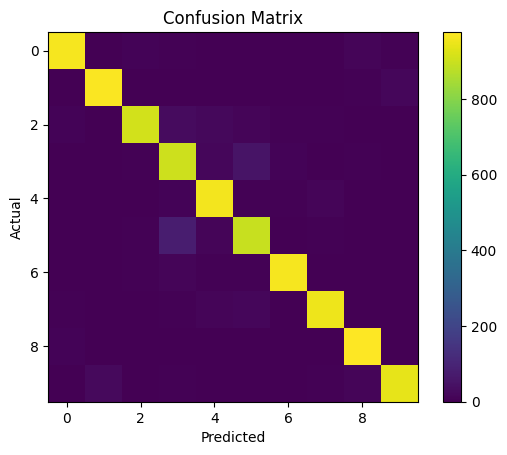

In [ ]:
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show